# 4 глава. Первичный анализ набора текстовых данных

Набор данных: **Email Spam Classification Dataset**  
Тип задачи: **бинарная классификация спама**  
Основные этапы: загрузка данных, анализ пропусков и дубликатов, очистка текста, лемматизация, частотный анализ, удаление стоп-слов, TF-IDF-векторизация и информационный поиск.

## 1. Импорт библиотек

In [ ]:
import os
import re
from collections import Counter

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 2. Загрузка набора данных

In [3]:
# Загрузка датасета с Kaggle

path = kagglehub.dataset_download("purusinghvi/email-spam-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 43.0M/43.0M [00:00<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/purusinghvi/email-spam-classification-dataset/versions/1


## 3. Чтение файла и первичный просмотр данных

In [4]:
# Чтение CSV-файла

df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

display(df.head())
print("Столбцы датасета:")
print(df.columns.tolist())
print("\nРазмер датасета:", df.shape)

Index(['label', 'text'], dtype='object')

## 4. Анализ пропусков и дубликатов

In [41]:
# Проверка пропущенных значений и дубликатов

print("Пропуски по столбцам:")
print(df.isna().sum())

print("\nОбщее количество пропущенных значений:")
print(df.isna().sum().sum())

print("\nКоличество полных дубликатов строк:")
print(df.duplicated().sum())

print("\nКоличество дубликатов по тексту письма:")
print(df['text'].duplicated().sum())

Пропуски по столбцам:
label             0
text              0
text_len          0
clean_text        0
clean_text_len    0
lemmas            0
no_stopwords      0
dtype: int64

Общее количество пропущенных значений:
0

Количество полных дубликатов строк:
0

Количество дубликатов по тексту письма:
2


## 5. Очистка текстов

**Таблица 10. Примеры очистки текстов электронных писем**

In [9]:
# Очистка текстов электронных писем

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df['text_len'] = df['text'].astype(str).apply(len)
df['clean_text_len'] = df['clean_text'].astype(str).apply(len)

display(df[['text', 'clean_text', 'text_len', 'clean_text_len']].head())

,text,clean_text,text_len,clean_text_len
0,ounce feather bowl hummingbird opec moment ala...,ounce feather bowl hummingbird opec moment ala...,148,148
1,wulvob get your medircations online qnb ikud v...,wulvob get your medircations online qnb ikud v...,808,808
2,computer connection from cnn com wednesday es...,computer connection from cnn com wednesday esc...,2235,2233
3,university degree obtain a prosperous future m...,university degree obtain a prosperous future m...,592,591
4,thanks for all your answers guys i know i shou...,thanks for all your answers guys i know i shou...,1362,1313


## 6. Лемматизация текста

**Таблица 11. Примеры лемматизации слов из текстов электронных писем**

In [10]:
# Лемматизация текста

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

word = "messages"
lemma = lemmatizer.lemmatize(word)

print("Пример работы лемматизации:")
print(f"Слово: {word}")
print(f"Лемма: {lemma}")

def lemmatize_text(text):
    words = text.split()
    lemmas = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmas)

df['lemmas'] = df['clean_text'].apply(lemmatize_text)

examples = []

for text in df['clean_text'].head(1000):
    words = text.split()
    for word in words:
        lemma = lemmatizer.lemmatize(word)
        if word != lemma:
            examples.append([word, lemma])
    if len(examples) >= 5:
        break

lemma_examples = pd.DataFrame(
    examples[:5],
    columns=['Исходное слово', 'Лемма']
)

display(lemma_examples)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Пример работы лемматизации:
Слово: messages
Лемма: message


,Исходное слово,Лемма
0,pays,pay
1,painkillers,painkiller
2,drugs,drug
3,tablets,tablet
4,costs,cost


## 7. Частотный анализ слов

**Таблица 12. Наиболее частотные слова в корпусе электронных писем**  
**Рисунок 20. Топ-10 наиболее частотных слов в корпусе писем**  
**Рисунок 21. Облако слов корпуса электронных писем**

,Слово,Частота
0,escapenumber,1148051
1,the,720607
2,to,478475
3,a,410184
4,and,355690
5,of,337122
6,in,246413
7,escapelong,227296
8,you,195110
9,for,191315


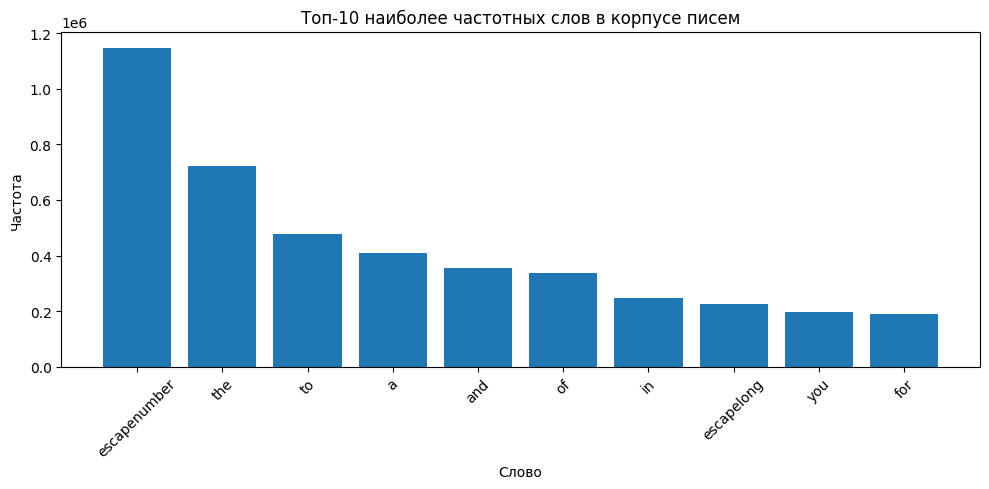

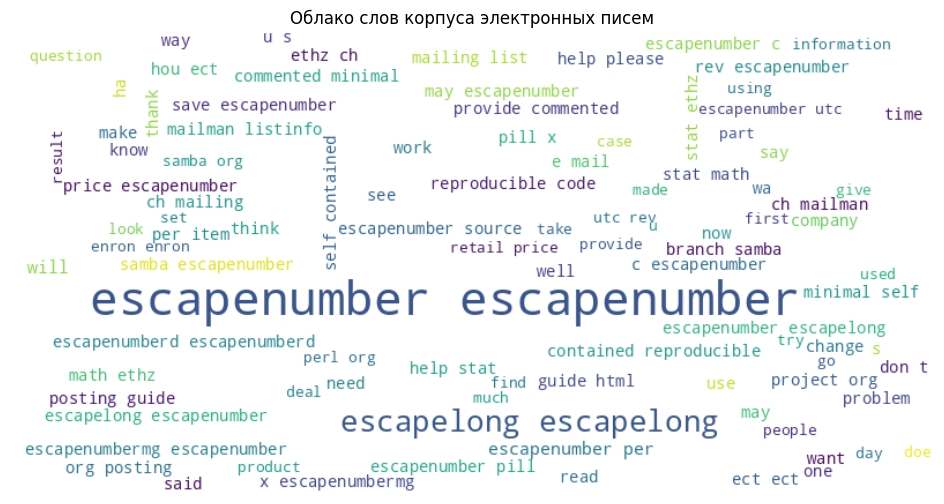

In [13]:
# Частотный анализ слов

all_words = ' '.join(df['lemmas']).split()

word_counts = Counter(all_words)

freq_df = pd.DataFrame(
    word_counts.most_common(10),
    columns=['Слово', 'Частота']
)

display(freq_df)

plt.figure(figsize=(10, 5))
plt.bar(freq_df['Слово'], freq_df['Частота'])
plt.title('Рисунок 20. Топ-10 наиболее частотных слов в корпусе писем')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

all_text = ' '.join(df['lemmas'])

wordcloud = WordCloud(
    width=800,
    height=400,
    max_words=100,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Рисунок 21. Облако слов корпуса электронных писем')
plt.show()

## 8. Удаление стоп-слов

**Рисунок 22. Топ-10 слов после удаления стоп-слов**

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Стоп-слово
0,a
1,about
2,above
3,after
4,again
...,...
95,mightn't
96,more
97,most
98,mustn


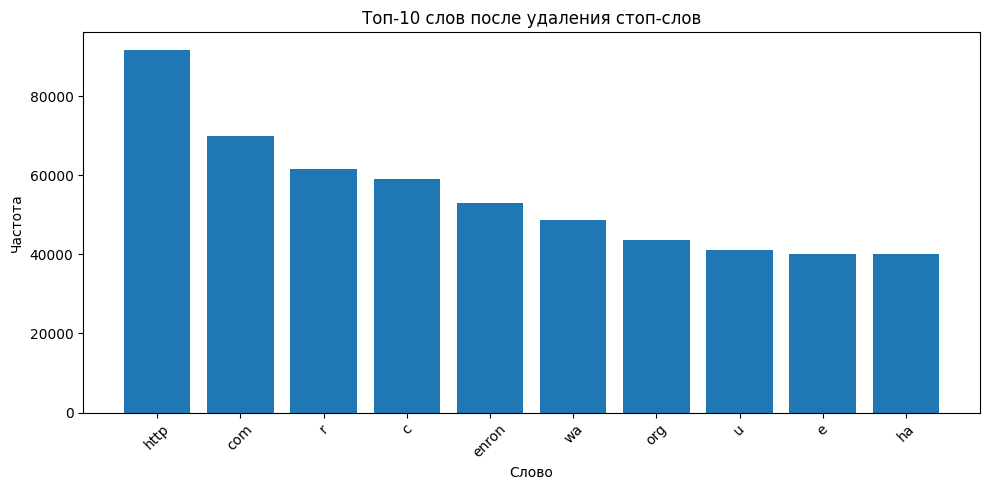

In [17]:
# Удаление стоп-слов

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

custom_stopwords = {'escapenumber', 'escapelong'}

stop_words = stop_words.union(custom_stopwords)

stopwords_examples = pd.DataFrame(
    sorted(list(stop_words))[:20],
    columns=['Стоп-слово']
)

display(stopwords_examples)

def remove_stopwords(text):
    words = str(text).split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['no_stopwords'] = df['lemmas'].apply(remove_stopwords)

all_words_no_stop = ' '.join(df['no_stopwords'].dropna()).split()
word_counts_no_stop = Counter(all_words_no_stop)

freq_no_stop_df = pd.DataFrame(
    word_counts_no_stop.most_common(10),
    columns=['Слово', 'Частота']
)

display(freq_no_stop_df)

plt.figure(figsize=(10, 5))
plt.bar(freq_no_stop_df['Слово'], freq_no_stop_df['Частота'])
plt.title('Рисунок 22. Топ-10 слов после удаления стоп-слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. TF-IDF-векторизация корпуса

**Таблица 13. Пример TF-IDF-вектора для одного электронного письма**

In [27]:
# TF-IDF-векторизация корпуса

vectorizer = TfidfVectorizer(max_features=5000)

tfidf_matrix = vectorizer.fit_transform(df['no_stopwords'])

feature_names = vectorizer.get_feature_names_out()

print("Тексты электронных писем преобразованы в матрицу TF-IDF.")
print(f"Размерность полученной матрицы: {tfidf_matrix.shape[0]} строк на {tfidf_matrix.shape[1]} признаков.")
print(f"Размер словаря: {len(feature_names)} слов.\n")

doc_index = df[df['no_stopwords'].apply(lambda x: len(str(x).split())) > 20].index[0]

print(f"Текст: {df.loc[doc_index, 'no_stopwords'][:500]}...\n")

vector = tfidf_matrix[doc_index]

nonzero_indices = vector.nonzero()[1]

tfidf_example_df = pd.DataFrame({
    'Слово': feature_names[nonzero_indices],
    'TF-IDF': vector.data
})

tfidf_example_df = tfidf_example_df.sort_values(
    by='TF-IDF',
    ascending=False
).head(10)

tfidf_example_df = tfidf_example_df.reset_index(drop=True)
tfidf_example_df.index = tfidf_example_df.index + 1

display(tfidf_example_df)

[ИТОГ] Тексты электронных писем преобразованы в матрицу TF-IDF.
[ИТОГ] Размерность полученной матрицы: 83448 строк на 5000 признаков.
[ИТОГ] Размер словаря: 5000 слов.

Текст: wulvob get medircations online qnb ikud viagra levitra cialis imitrex flonax ultram vioxx ambien valium xannax soma meridia cysfrt ever stopped wonder much average man pay mediecines ap painkiller drug improve quality life weight reducing tablet many worse mediucine cost lot branded rfwur intrested http dmvrwm remunerativ net dfuaeirxygiq visit website...



,Слово,TF-IDF
1,valium,0.261523
2,tablet,0.259899
3,soma,0.248088
4,worse,0.236762
5,reducing,0.231613
6,stopped,0.225328
7,ap,0.217375
8,levitra,0.215117
9,wonder,0.213749
10,average,0.201981


## 10. Реализация информационного поиска по корпусу

**Таблица 14. Результаты информационного поиска по запросу free sample product offer**

In [38]:
# Информационный поиск по корпусу

def search_texts(query, vectorizer, tfidf_matrix, texts, labels, top_n=5):
    query_vec = vectorizer.transform([query])

    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

    top_indices = similarities.argsort()[-top_n:][::-1]

    results = pd.DataFrame({
        'Текст письма': texts.iloc[top_indices].values,
        'Класс': labels.iloc[top_indices].values,
        'Похожесть': similarities[top_indices]
    })

    return results

query = "free sample product offer"

results = search_texts(
    query,
    vectorizer,
    tfidf_matrix,
    df['no_stopwords'],
    df['label'],
    top_n=5
)

print(f"Поисковый запрос: '{query}'")
print(f"\nНайдено {len(results)} наиболее похожих писем:\n")

display(results)

Поисковый запрос: 'free sample product offer'

Найдено 5 наиболее похожих писем:



,Текст письма,Класс,Похожесть
0,free offer free offer free offer free offer kn...,1,0.671220
1,powered product sample product sample independ...,1,0.566538
2,message ha sent elist mate free revlon sample ...,1,0.540059
3,registered receive similar offer coppertone co...,1,0.534493
4,downey simple pleasure r fabric softener sampl...,1,0.530462


## 11. Итог

Ноутбук содержит код для первичного анализа текстового набора данных: проверку пропусков и дубликатов, очистку текста, лемматизацию, частотный анализ, удаление стоп-слов, TF-IDF-векторизацию и информационный поиск по корпусу.